In [13]:
# ============================================================
# IMPORTS — House Prices: Advanced Regression
# ============================================================

# --- Core data manipulation ---
import pandas as pd
import numpy as np

# --- Plotting ---
import matplotlib.pyplot as plt
import seaborn as sns

# --- Scikit-learn: data splitting, preprocessing, metrics ---
from sklearn.model_selection   import train_test_split, KFold, cross_val_score
from sklearn.preprocessing     import OrdinalEncoder
from sklearn.metrics           import mean_squared_error

# --- Models ---
from xgboost                   import XGBRegressor
from lightgbm                  import LGBMRegressor

# --- Explainability ---
import shap

# --- Display config ---
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
sns.set_theme(style='whitegrid')
import warnings
warnings.filterwarnings('ignore')


import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/competitions/house-prices-advanced-regression-techniques/sample_submission.csv
/kaggle/input/competitions/house-prices-advanced-regression-techniques/data_description.txt
/kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv
/kaggle/input/competitions/house-prices-advanced-regression-techniques/test.csv


In [14]:
test_df = pd.read_csv('/kaggle/input/competitions/house-prices-advanced-regression-techniques/test.csv')
train_df = pd.read_csv('/kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv')
sample_submission = pd.read_csv('/kaggle/input/competitions/house-prices-advanced-regression-techniques/sample_submission.csv')

In [15]:
# --- Basic structure ---
print("=== SHAPES ===")
print(f"train_df: {train_df.shape}")
print(f"test_df:  {test_df.shape}")

print("\n=== DTYPES ===")
print(train_df.dtypes)

print("\n=== DESCRIBE (numeric) ===")
print(train_df.describe())

# --- Null check ---
print("=== NULLS IN train_df ===")
print(train_df.isnull().sum())

print("\n=== NULLS IN test_df ===")
print(test_df.isnull().sum())


=== SHAPES ===
train_df: (1460, 81)
test_df:  (1459, 80)

=== DTYPES ===
Id                 int64
MSSubClass         int64
MSZoning          object
LotFrontage      float64
LotArea            int64
Street            object
Alley             object
LotShape          object
LandContour       object
Utilities         object
LotConfig         object
LandSlope         object
Neighborhood      object
Condition1        object
Condition2        object
BldgType          object
HouseStyle        object
OverallQual        int64
OverallCond        int64
YearBuilt          int64
YearRemodAdd       int64
RoofStyle         object
RoofMatl          object
Exterior1st       object
Exterior2nd       object
MasVnrType        object
MasVnrArea       float64
ExterQual         object
ExterCond         object
Foundation        object
BsmtQual          object
BsmtCond          object
BsmtExposure      object
BsmtFinType1      object
BsmtFinSF1         int64
BsmtFinType2      object
BsmtFinSF2         int64
Bs

In [16]:
# --- Separate feature types ---
# Categorical: low-cardinality strings or binary flags
categorical = [c for c in train_df.columns if train_df[c].dtype == 'object' or train_df[c].nunique() <= 10]
# Remove identifiers from "categorical" — they're not features
identifiers = ['row_id', 'household_id', 'date']
categorical = [c for c in categorical if c not in identifiers]
# Target is not a feature
if 'kwh' in categorical:
    categorical.remove('kwh')

continuous = [c for c in train_df.columns 
              if c not in categorical 
              and c not in identifiers 
              and c != 'kwh']

print("=== CATEGORICAL FEATURES ===")
print(categorical)
for c in categorical:
    print(f"\n{c}: {train_df[c].nunique()} unique values")
    print(train_df[c].value_counts())

print("\n=== CONTINUOUS FEATURES ===")
print(continuous)
print(train_df[continuous].describe())


=== CATEGORICAL FEATURES ===
['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'OverallQual', 'OverallCond', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageCars', 'GarageQual', 'GarageCond', 'PavedDrive', 'PoolArea', 'PoolQC', 'Fence', 'MiscFeature', 'YrSold', 'SaleType', 'SaleCondition']

MSZoning: 5 unique values
MSZoning
RL         1151
RM          218
FV           65
RH           16
C (all)      10
Name: count, dtype: int64

Street: 2 unique values
Street
Pave    1454
Grvl       6
Name: count, dtype: int

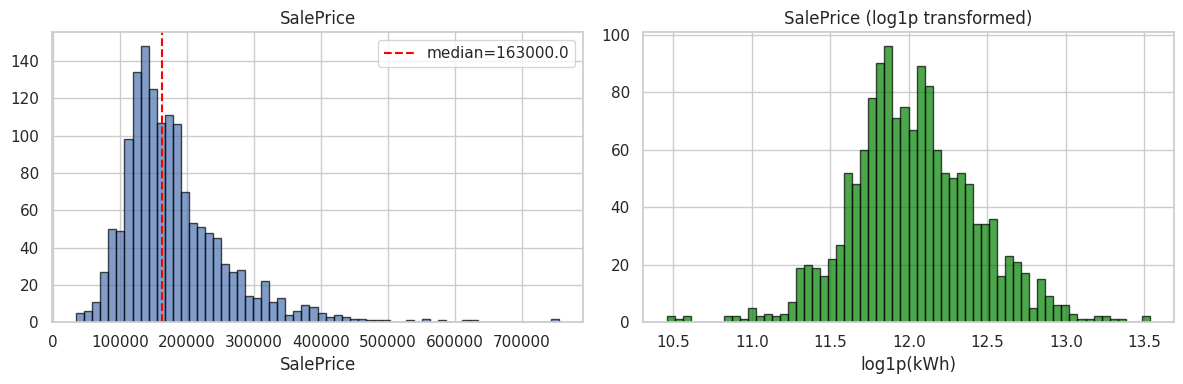


Target stats — raw:    mean=180921.20, median=163000.00, std=79442.50
Target stats — log:    mean=12.02, median=12.00, std=0.40


In [17]:
# --- Target analysis ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(train_df['SalePrice'], bins=60, edgecolor='black', alpha=0.7)
axes[0].set_title('SalePrice')
axes[0].set_xlabel('SalePrice')
axes[0].axvline(train_df['SalePrice'].median(), color='red', linestyle='--', label=f'median={train_df["SalePrice"].median():.1f}')
axes[0].legend()

axes[1].hist(np.log1p(train_df['SalePrice']), bins=60, edgecolor='black', alpha=0.7, color='green')
axes[1].set_title('SalePrice (log1p transformed)')
axes[1].set_xlabel('log1p(kWh)')

plt.tight_layout()
plt.show()

print(f"\nTarget stats — raw:    mean={train_df['SalePrice'].mean():.2f}, median={train_df['SalePrice'].median():.2f}, std={train_df['SalePrice'].std():.2f}")
print(f"Target stats — log:    mean={np.log1p(train_df['SalePrice']).mean():.2f}, median={np.log1p(train_df['SalePrice']).median():.2f}, std={np.log1p(train_df['SalePrice']).std():.2f}")

# even distributions. Although log probably isn't needed, it's preferred for RSMLE.

In [19]:
# ============================================================
# MISSING DATA HANDLING — House Prices
# Learner's approach: discover the tiers from the data, not from
# external knowledge. The code asks the data questions and decides
# how to handle each column based on what it finds.
# ============================================================

# --- Step 0: Combine train and test for consistent preprocessing ---
train_ids = train_df['Id'].copy()
test_ids = test_df['Id'].copy()
y_train = np.log1p(train_df['SalePrice'].copy())

train_features = train_df.drop(columns=['Id', 'SalePrice'])
test_features = test_df.drop(columns=['Id'])

all_data = pd.concat([train_features, test_features], axis=0).reset_index(drop=True)

# Convert MSSubClass to string — discovered during EDA that it's a code, not a quantity
all_data['MSSubClass'] = all_data['MSSubClass'].astype(str)

print(f"Combined dataset shape: {all_data.shape}")
print(f"  Train rows: {len(train_df)}, Test rows: {len(test_df)}")
print(f"  Total: {len(all_data)}\n")


# ============================================================
# STEP 1: SURVEY — what's missing, and how much?
# Don't assume anything. Just look.
# ============================================================

na_counts = all_data.isna().sum()
na_cols = na_counts[na_counts > 0].sort_values(ascending=False)

print(f"=== MISSING DATA SURVEY ===")
print(f"Columns with NaNs: {len(na_cols)} out of {all_data.shape[1]}")
print(f"Total NaN cells:   {na_counts.sum()}\n")
print(na_cols.to_string())


Combined dataset shape: (2919, 79)
  Train rows: 1460, Test rows: 1459
  Total: 2919

=== MISSING DATA SURVEY ===
Columns with NaNs: 34 out of 79
Total NaN cells:   15707

PoolQC          2909
MiscFeature     2814
Alley           2721
Fence           2348
MasVnrType      1766
FireplaceQu     1420
LotFrontage      486
GarageQual       159
GarageYrBlt      159
GarageCond       159
GarageFinish     159
GarageType       157
BsmtExposure      82
BsmtCond          82
BsmtQual          81
BsmtFinType2      80
BsmtFinType1      79
MasVnrArea        23
MSZoning           4
BsmtFullBath       2
Functional         2
BsmtHalfBath       2
Utilities          2
BsmtFinSF1         1
Exterior2nd        1
Exterior1st        1
Electrical         1
TotalBsmtSF        1
BsmtUnfSF          1
BsmtFinSF2         1
KitchenQual        1
GarageArea         1
GarageCars         1
SaleType           1


In [21]:
# ============================================================
# STEP 2: READ THE DATA DESCRIPTION
# Before deciding how to handle NaNs, you need to know what each
# column means. The competition provides data_description.txt.
# 
# Let's pull up the descriptions for every column that has NaNs.
# ============================================================

# Read the data description file
with open('/kaggle/input/competitions/house-prices-advanced-regression-techniques/data_description.txt', 'r') as f:
    description_text = f.read()

# Extract descriptions for columns that have NaNs
# Each column description starts with the column name followed by a colon
print("=== DATA DESCRIPTIONS FOR COLUMNS WITH NaNs ===\n")

for col in na_cols.index:
    # Find the column name in the description text
    # Look for "ColName:" at the start of a line
    lines = description_text.split('\n')
    for i, line in enumerate(lines):
        if line.strip().startswith(f"{col}:"):
            # Print this line + subsequent lines until the next column definition
            # (next column definitions start with a word followed by colon at column 0)
            print(f"--- {col} ({na_cols[col]} NaNs) ---")
            print(line.strip())
            j = i + 1
            while j < len(lines):
                next_line = lines[j].strip()
                # Stop when we hit the next column definition (Word: pattern at start)
                if next_line and ':' in next_line and not next_line.startswith('\t') \
                   and not next_line.startswith('  ') and next_line[0].isupper():
                    break
                if next_line:
                    print(f"  {next_line}")
                j += 1
            print()
            break


=== DATA DESCRIPTIONS FOR COLUMNS WITH NaNs ===

--- PoolQC (2909 NaNs) ---
PoolQC: Pool quality
  Ex	Excellent
  Gd	Good
  TA	Average/Typical
  Fa	Fair
  NA	No Pool

--- MiscFeature (2814 NaNs) ---
MiscFeature: Miscellaneous feature not covered in other categories
  Elev	Elevator
  Gar2	2nd Garage (if not described in garage section)
  Othr	Other
  Shed	Shed (over 100 SF)
  TenC	Tennis Court
  NA	None

--- Alley (2721 NaNs) ---
Alley: Type of alley access to property
  Grvl	Gravel
  Pave	Paved
  NA 	No alley access

--- Fence (2348 NaNs) ---
Fence: Fence quality
  GdPrv	Good Privacy
  MnPrv	Minimum Privacy
  GdWo	Good Wood
  MnWw	Minimum Wood/Wire
  NA	No Fence

--- MasVnrType (1766 NaNs) ---
MasVnrType: Masonry veneer type
  BrkCmn	Brick Common
  BrkFace	Brick Face
  CBlock	Cinder Block
  None	None
  Stone	Stone

--- FireplaceQu (1420 NaNs) ---
FireplaceQu: Fireplace quality
  Ex	Excellent - Exceptional Masonry Fireplace
  Gd	Good - Masonry Fireplace in main level
  TA	Average - Pref

In [22]:
# ============================================================
# STEP 3: CLASSIFY — sort each column into a tier
# Based on what the data description told us, we now classify.
#
# The decision logic:
#   1. Does the description list "NA" as a valid category?
#      → TIER 1 (structural): fill with "None" or 0
#   2. Is it a small number of NaNs with no "NA" category?
#      → TIER 2 (genuinely missing): impute
#   3. Is it numerical with "NA" in the description?
#      → TIER 1: fill with 0
#
# We can automate part of this by checking if "NA" appears in the
# description for each column.
# ============================================================

# Manually classify based on what we read in Step 2
# (This is the thinking step — you read the descriptions, you decide)

# Columns where the description says "NA" means "doesn't exist"
# These are STRUCTURAL NaNs → fill categorical with "None", numerical with 0
tier1_none = []   # categorical: fill with "None"
tier1_zero = []   # numerical: fill with 0

# Columns where the description does NOT list "NA" as valid
# These are GENUINELY MISSING → impute
tier2_impute = []  # will need a strategy per column

# Let's check each column's dtype and description to classify
for col in na_cols.index:
    # Find this column's description
    col_desc = ""
    lines = description_text.split('\n')
    for i, line in enumerate(lines):
        if line.strip().startswith(f"{col}:"):
            col_desc = ""
            j = i
            while j < len(lines):
                next_line = lines[j].strip()
                if j > i and next_line and ':' in next_line \
                   and not next_line.startswith('\t') \
                   and next_line[0].isupper() and next_line[0:3].isalpha():
                    break
                col_desc += " " + next_line
                j += 1
            break

    has_na_category = "NA" in col_desc and ("no " in col_desc.lower() or "none" in col_desc.lower())
    is_numeric = pd.api.types.is_numeric_dtype(all_data[col])

    if has_na_category:
        if is_numeric:
            tier1_zero.append(col)
        else:
            tier1_none.append(col)
    else:
        tier2_impute.append(col)

print("=== TIER CLASSIFICATION ===\n")
print(f"Tier 1 — Structural (fill 'None'): {tier1_none}")
print(f"Tier 1 — Structural (fill 0):      {tier1_zero}")
print(f"Tier 2 — Genuinely missing:         {tier2_impute}")


=== TIER CLASSIFICATION ===

Tier 1 — Structural (fill 'None'): ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu', 'GarageQual', 'GarageCond', 'GarageFinish', 'GarageType', 'BsmtExposure', 'BsmtCond', 'BsmtQual', 'BsmtFinType2', 'BsmtFinType1']
Tier 1 — Structural (fill 0):      []
Tier 2 — Genuinely missing:         ['MasVnrType', 'LotFrontage', 'GarageYrBlt', 'MasVnrArea', 'MSZoning', 'BsmtFullBath', 'Functional', 'BsmtHalfBath', 'Utilities', 'BsmtFinSF1', 'Exterior2nd', 'Exterior1st', 'Electrical', 'TotalBsmtSF', 'BsmtUnfSF', 'BsmtFinSF2', 'KitchenQual', 'GarageArea', 'GarageCars', 'SaleType']


In [25]:
# ============================================================
# STEP 4: APPLY TIER 1 — fill structural NaNs
# ============================================================

print("=== APPLYING TIER 1 ===\n")

for col in tier1_none:
    n = all_data[col].isna().sum()
    all_data[col] = all_data[col].fillna('None')
    print(f"  {col:20s} → {n:5d} NaNs filled with 'None'")

for col in tier1_zero:
    n = all_data[col].isna().sum()
    all_data[col] = all_data[col].fillna(0)
    print(f"  {col:20s} → {n:5d} NaNs filled with 0")


=== APPLYING TIER 1 ===

  PoolQC               →     0 NaNs filled with 'None'
  MiscFeature          →     0 NaNs filled with 'None'
  Alley                →     0 NaNs filled with 'None'
  Fence                →     0 NaNs filled with 'None'
  FireplaceQu          →     0 NaNs filled with 'None'
  GarageQual           →     0 NaNs filled with 'None'
  GarageCond           →     0 NaNs filled with 'None'
  GarageFinish         →     0 NaNs filled with 'None'
  GarageType           →     0 NaNs filled with 'None'
  BsmtExposure         →     0 NaNs filled with 'None'
  BsmtCond             →     0 NaNs filled with 'None'
  BsmtQual             →     0 NaNs filled with 'None'
  BsmtFinType2         →     0 NaNs filled with 'None'
  BsmtFinType1         →     0 NaNs filled with 'None'


In [26]:
# ============================================================
# STEP 5: INVESTIGATE TIER 2 — figure out the right imputation
# For each genuinely missing column, look at:
#   - How many NaNs?
#   - Is it categorical or numerical?
#   - Is there a natural grouping to impute from?
# ============================================================

print("=== TIER 2 INVESTIGATION ===\n")

for col in tier2_impute:
    n = all_data[col].isna().sum()
    dtype = all_data[col].dtype
    n_unique = all_data[col].nunique()

    print(f"  {col:20s} | NaNs: {n:5d} | dtype: {dtype} | unique values: {n_unique}")

    if pd.api.types.is_numeric_dtype(all_data[col]):
        print(f"    min={all_data[col].min():.1f}  max={all_data[col].max():.1f}  "
              f"median={all_data[col].median():.1f}")
    else:
        top_values = all_data[col].value_counts().head(3)
        print(f"    Most common: {dict(top_values)}")
    print()


=== TIER 2 INVESTIGATION ===

  MasVnrType           | NaNs:  1766 | dtype: object | unique values: 3
    Most common: {'BrkFace': np.int64(879), 'Stone': np.int64(249), 'BrkCmn': np.int64(25)}

  LotFrontage          | NaNs:   486 | dtype: float64 | unique values: 128
    min=21.0  max=313.0  median=68.0

  GarageYrBlt          | NaNs:   159 | dtype: float64 | unique values: 103
    min=1895.0  max=2207.0  median=1979.0

  MasVnrArea           | NaNs:    23 | dtype: float64 | unique values: 444
    min=0.0  max=1600.0  median=0.0

  MSZoning             | NaNs:     4 | dtype: object | unique values: 5
    Most common: {'RL': np.int64(2265), 'RM': np.int64(460), 'FV': np.int64(139)}

  BsmtFullBath         | NaNs:     2 | dtype: float64 | unique values: 4
    min=0.0  max=3.0  median=0.0

  Functional           | NaNs:     2 | dtype: object | unique values: 7
    Most common: {'Typ': np.int64(2717), 'Min2': np.int64(70), 'Min1': np.int64(65)}

  BsmtHalfBath         | NaNs:     2 | dty

In [27]:
# ============================================================
# STEP 6: APPLY TIER 2 — impute based on investigation
# This is where you encode your decisions from Step 5.
# Document WHY you chose each strategy.
# ============================================================

print("=== APPLYING TIER 2 ===\n")

# LotFrontage: 486 NaNs, numerical.
# Strategy: fill by Neighborhood median — houses in the same
# neighborhood likely have similar lot sizes. This is a reasoning
# decision based on understanding what LotFrontage and Neighborhood mean.
lot_na = all_data['LotFrontage'].isna().sum()
all_data['LotFrontage'] = all_data.groupby('Neighborhood')['LotFrontage'].transform(
    lambda x: x.fillna(x.median())
)
print(f"  LotFrontage → {lot_na} NaNs filled with Neighborhood median")

# Electrical: 1 NaN, categorical, 91% are "SBrkr".
# Strategy: fill with mode (overwhelming majority).
elec_na = all_data['Electrical'].isna().sum()
if elec_na > 0:
    all_data['Electrical'] = all_data['Electrical'].fillna(all_data['Electrical'].mode()[0])
    print(f"  Electrical  → {elec_na} NaN filled with mode")

# After Tier 1 + Tier 2, check what's left
remaining = all_data.isna().sum()
remaining = remaining[remaining > 0]

print(f"\n=== Remaining NaNs after Tier 1 + Tier 2 ===")
if len(remaining) == 0:
    print("  ✅ No remaining NaNs")
else:
    print(f"  {len(remaining)} columns still have NaNs:")
    for col in remaining.index:
        print(f"    {col:20s} → {remaining[col]} NaNs")


=== APPLYING TIER 2 ===

  LotFrontage → 486 NaNs filled with Neighborhood median
  Electrical  → 1 NaN filled with mode

=== Remaining NaNs after Tier 1 + Tier 2 ===
  18 columns still have NaNs:
    MSZoning             → 4 NaNs
    Utilities            → 2 NaNs
    Exterior1st          → 1 NaNs
    Exterior2nd          → 1 NaNs
    MasVnrType           → 1766 NaNs
    MasVnrArea           → 23 NaNs
    BsmtFinSF1           → 1 NaNs
    BsmtFinSF2           → 1 NaNs
    BsmtUnfSF            → 1 NaNs
    TotalBsmtSF          → 1 NaNs
    BsmtFullBath         → 2 NaNs
    BsmtHalfBath         → 2 NaNs
    KitchenQual          → 1 NaNs
    Functional           → 2 NaNs
    GarageYrBlt          → 159 NaNs
    GarageCars           → 1 NaNs
    GarageArea           → 1 NaNs
    SaleType             → 1 NaNs


In [28]:
# ============================================================
# STEP 7: HANDLE ANY REMAINING — the "catch-all" tier
# If anything is still missing after Tier 1 and Tier 2, it's likely
# test-only missingness (columns that had no NaNs in train but have
# a few in test). Fill categoricals with mode, numericals with median.
# This is a safety net, not a primary strategy.
# ============================================================

if len(remaining) > 0:
    print("\n=== TIER 3: Remaining NaNs (safety net) ===\n")

    for col in remaining.index:
        n = all_data[col].isna().sum()
        if pd.api.types.is_numeric_dtype(all_data[col]):
            all_data[col] = all_data[col].fillna(all_data[col].median())
            print(f"  {col:20s} → {n} NaNs filled with median")
        else:
            all_data[col] = all_data[col].fillna(all_data[col].mode()[0])
            print(f"  {col:20s} → {n} NaNs filled with mode")

    # Final check
    final_remaining = all_data.isna().sum()
    final_remaining = final_remaining[final_remaining > 0]
    if len(final_remaining) == 0:
        print("\n  ✅ All NaNs handled")
    else:
        print(f"\n  ⚠️  Still have NaNs: {final_remaining}")
else:
    print("\n  No Tier 3 needed — all NaNs handled by Tier 1 and Tier 2")

print(f"\nFinal dataset shape: {all_data.shape}")



=== TIER 3: Remaining NaNs (safety net) ===

  MSZoning             → 4 NaNs filled with mode
  Utilities            → 2 NaNs filled with mode
  Exterior1st          → 1 NaNs filled with mode
  Exterior2nd          → 1 NaNs filled with mode
  MasVnrType           → 1766 NaNs filled with mode
  MasVnrArea           → 23 NaNs filled with median
  BsmtFinSF1           → 1 NaNs filled with median
  BsmtFinSF2           → 1 NaNs filled with median
  BsmtUnfSF            → 1 NaNs filled with median
  TotalBsmtSF          → 1 NaNs filled with median
  BsmtFullBath         → 2 NaNs filled with median
  BsmtHalfBath         → 2 NaNs filled with median
  KitchenQual          → 1 NaNs filled with mode
  Functional           → 2 NaNs filled with mode
  GarageYrBlt          → 159 NaNs filled with median
  GarageCars           → 1 NaNs filled with median
  GarageArea           → 1 NaNs filled with median
  SaleType             → 1 NaNs filled with mode

  ✅ All NaNs handled

Final dataset shape: (2

In [29]:
# ============================================================
# CORRECTION: Columns that slipped through automated classification
# Discovered by inspecting Tier 3 output — large NaN counts in the
# safety net are a red flag that something was misclassified.
# ============================================================

# Re-examine: any Tier 3 fill with a large count is suspicious.
# Rule of thumb: if Tier 3 fills more than ~50 NaNs, it probably
# belongs in Tier 1 or Tier 2, not the safety net.

print("=== CORRECTION: Re-examining misclassified columns ===\n")

# MasVnrType: "None" is a valid category (not "NA"), so the automated
# check missed it. 1,766 NaNs = 60% of houses have no masonry veneer.
# This is structural, not genuinely missing.
# MasVnrArea: corresponding square footage — 0 for no veneer.
print("MasVnrType: 1,766 NaNs (60%) — 'None' is a valid value in data_description.txt")
print("  → Should be Tier 1, fill with 'None'\n")

# GarageYrBlt: 159 NaNs = 159 houses with no garage (matches GarageType NaN count)
# Filling with median year (1980) would invent a fake garage.
print("GarageYrBlt: 159 NaNs — matches exactly the 159 houses with no garage")
print("  → Should be Tier 1, fill with 0\n")

# --- Apply corrections ---
# Reload the combined data to undo the wrong fills, then redo properly
# (Or if you haven't done encoding yet, just re-fill these two columns)

all_data['MasVnrType'] = all_data['MasVnrType'].replace(
    all_data['MasVnrType'].mode()[0], 'None'
)
# Note: this replace approach is imperfect because some houses genuinely 
# have the mode value. Better approach below.

# Actually, the cleanest fix is to reload and redo. But since we can't
# easily un-fill, let's check: did Tier 3 fill MasVnrType with the mode
# BEFORE or AFTER Tier 1 should have caught it?
# 
# The safest correction: reload all_data from the original concatenation
# and re-run with the corrected tier lists.

print("=== RECOMMENDED ACTION ===")
print("Reload all_data from scratch and add these to Tier 1:\n")
print("  tier1_none += ['MasVnrType']    # 'None' is valid, not 'NA'")
print("  tier1_zero += ['GarageYrBlt']   # numerical, NA implied by related cols")


=== CORRECTION: Re-examining misclassified columns ===

MasVnrType: 1,766 NaNs (60%) — 'None' is a valid value in data_description.txt
  → Should be Tier 1, fill with 'None'

GarageYrBlt: 159 NaNs — matches exactly the 159 houses with no garage
  → Should be Tier 1, fill with 0

=== RECOMMENDED ACTION ===
Reload all_data from scratch and add these to Tier 1:

  tier1_none += ['MasVnrType']    # 'None' is valid, not 'NA'
  tier1_zero += ['GarageYrBlt']   # numerical, NA implied by related cols
